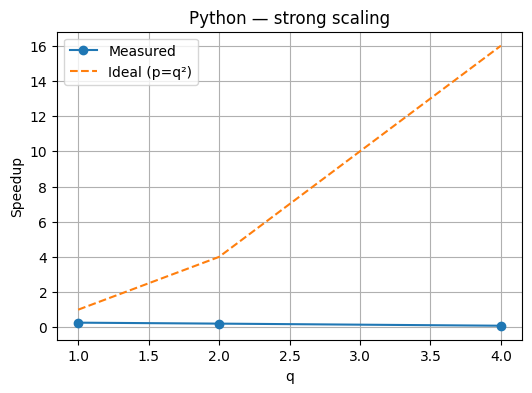

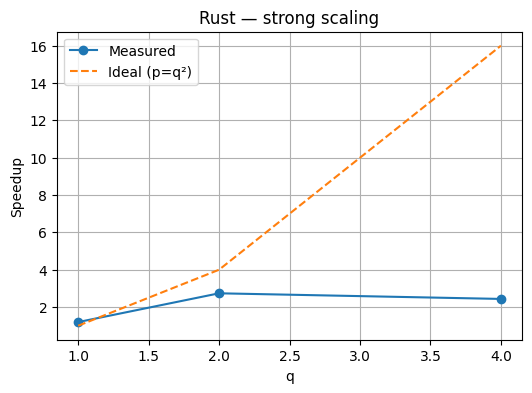

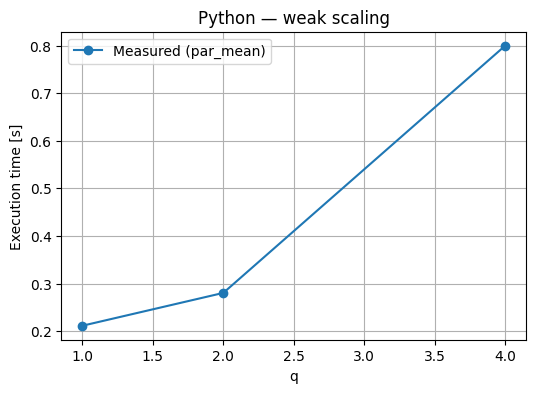

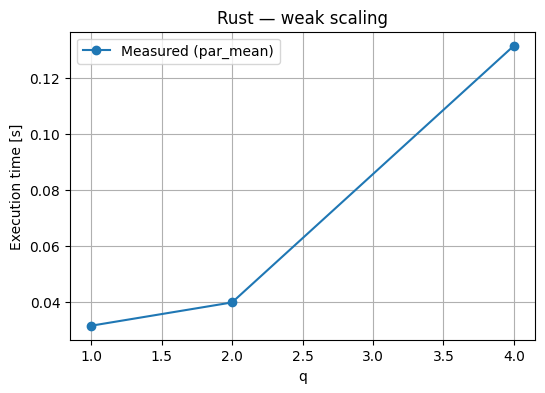

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def load_csv(path):
    df = pd.read_csv(path)
    # Očekujemo kolone: q, speedup i (za weak) par_mean
    # Ako q nije numerički, probaj konverziju
    if 'q' in df.columns:
        df['q'] = pd.to_numeric(df['q'], errors='coerce')
        df = df.dropna(subset=['q'])
    return df

def plot_strong(path, title):
    df = load_csv(path)
    if 'speedup' not in df.columns:
        raise ValueError(f"{path} nema kolonu 'speedup'")
    q = df['q'].to_numpy()
    p = q**2  # p = q^2
    plt.figure(figsize=(6,4))
    plt.plot(q, df['speedup'], 'o-', label='Measured')
    plt.plot(q, p, '--', label='Ideal (p=q²)')
    plt.xlabel('q')
    plt.ylabel('Speedup')
    plt.title(title)
    plt.legend(); plt.grid(True); plt.show()

def plot_weak(path, title):
    df = load_csv(path)
    # Preferiramo paralelno vreme; fallback na seq_mean ako nema
    ycol = 'par_mean' if 'par_mean' in df.columns else ('seq_mean' if 'seq_mean' in df.columns else None)
    if ycol is None:
        raise ValueError(f"{path} nema 'par_mean' ili 'seq_mean'")
    q = df['q'].to_numpy()
    plt.figure(figsize=(6,4))
    plt.plot(q, df[ycol], 'o-', label=f'Measured ({ycol})')
    plt.xlabel('q')
    plt.ylabel('Execution time [s]')
    plt.title(title)
    plt.legend(); plt.grid(True); plt.show()


#PYTHON BUILD INSTRUCTIONS:
# How to get Results for Python version for Amdahl's and Gustafson's laws plots:
# cd python
# STRONG scaling (3 vrednosti q = 1,2,4, 30 ponavljanja)
# python bench_py.py --mode strong_py --n 1024 --bs 128 --q_list 1,2,4 --reps 30 --out ../data/logs/strong_py.csv
# WEAK scaling (3 vrednosti q = 1,2,4, 30 ponavljanja)
# python bench_py.py --mode weak_py --bs 128 --q_list 1,2,4 --reps 30 --out ../data/logs/weak_py.csv
# strong
plot_strong('../data/logs/strong_py.csv', 'Python — strong scaling')
plot_strong('../data/logs/strong_rs.csv', 'Rust — strong scaling')

#RUST BUILD INSTRUCTIONS:
# How to get Results for Rust version for Amdahl's and Gustafson's laws plots:
# cd ../rust
# cargo build --release
# STRONG scaling (3 vrednosti q = 1,2,4, 30 ponavljanja)
# .\target\release\bench_rs.exe strong_rs 1,2,4 1024 128 30 ..\data\logs\strong_rs.csv
# WEAK scaling (3 vrednosti q = 1,2,4, 30 ponavljanja)
# .\target\release\bench_rs.exe weak_rs 1,2,4 1024 128 30 ..\data\logs\weak_rs.csv
# weak
plot_weak('../data/logs/weak_py.csv', 'Python — weak scaling')
plot_weak('../data/logs/weak_rs.csv', 'Rust — weak scaling')